In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import random
import pandas as pd
import pydicom
import cv2
import numpy as np
from tqdm import tqdm

DICOM_DIR = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train"
CSV_PATH = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv"
OUTPUT_DIR = "/kaggle/working/png_5000_balanced"

os.makedirs(OUTPUT_DIR, exist_ok=True)


df = pd.read_csv(CSV_PATH)

# Remove duplicate boxes (important)
df_unique = df[['image_id', 'class_id']].drop_duplicates()

# Number of classes
num_classes = df_unique['class_id'].nunique()
print("Number of classes:", num_classes)

# Target
TARGET_TOTAL = 5000
per_class = TARGET_TOTAL // num_classes

selected_images = []

# ===== BALANCED SELECTION ===
for class_id in df_unique['class_id'].unique():
    class_images = df_unique[df_unique['class_id'] == class_id]['image_id'].unique().tolist()

    if len(class_images) <= per_class:
        selected_images.extend(class_images)
    else:
        selected_images.extend(random.sample(class_images, per_class))

# If slightly less due to rounding, fill randomly
if len(selected_images) < TARGET_TOTAL:
    all_images = df_unique['image_id'].unique().tolist()
    remaining = list(set(all_images) - set(selected_images))
    selected_images.extend(random.sample(remaining, TARGET_TOTAL - len(selected_images)))

print("Total selected:", len(selected_images))

# ===== CONVERT TO PNG =====
saved = 0

for image_id in tqdm(selected_images):
    dicom_path = os.path.join(DICOM_DIR, image_id + ".dicom")

    if not os.path.exists(dicom_path):
        continue

    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)

    # Fix MONOCHROME1
    if ds.PhotometricInterpretation == "MONOCHROME1":
        img = np.max(img) - img

    # Normalize
    img -= img.min()
    if img.max() != 0:
        img /= img.max()
    img = (img * 255).astype(np.uint8)

    cv2.imwrite(os.path.join(OUTPUT_DIR, image_id + ".png"), img)
    saved += 1

print("✅ PNG images saved:", saved)


Number of classes: 15
Total selected: 5000


100%|██████████| 5000/5000 [1:42:12<00:00,  1.23s/it]  

✅ PNG images saved: 5000


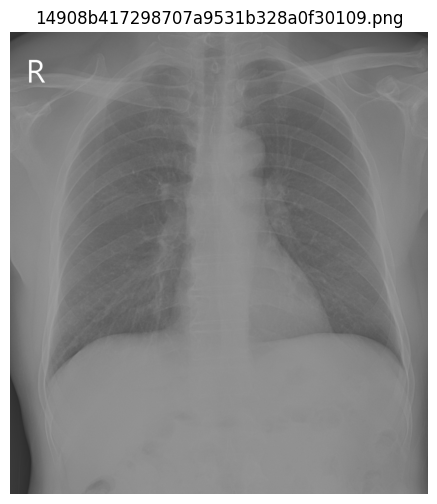

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import random

OUTPUT_DIR = "/kaggle/working/png_5000_balanced"

# Pick random image
files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".png")]
sample_file = random.choice(files)

# Read image
img_path = os.path.join(OUTPUT_DIR, sample_file)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Display
plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title(sample_file)
plt.axis("off")
plt.show()


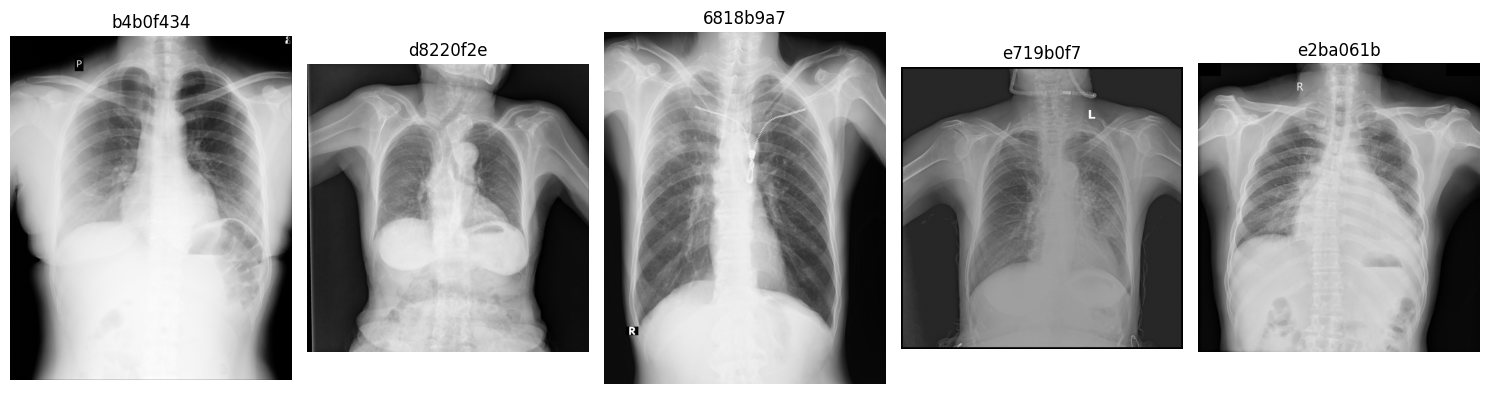

In [3]:
plt.figure(figsize=(15,5))

for i in range(5):
    sample_file = random.choice(files)
    img = cv2.imread(os.path.join(OUTPUT_DIR, sample_file), cv2.IMREAD_GRAYSCALE)

    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(sample_file[:8])
    plt.axis("off")

plt.tight_layout()
plt.show()


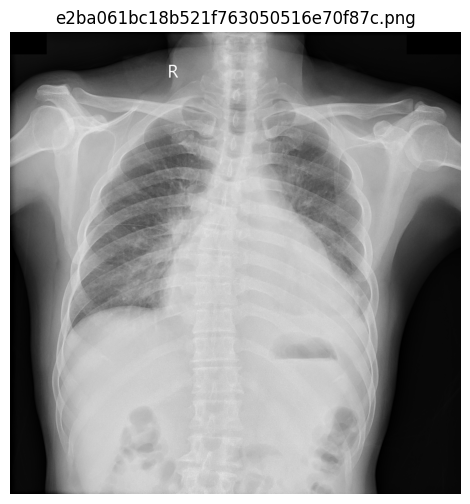

In [5]:
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title(f"{sample_file}")
plt.axis("off")
plt.show()


In [8]:
classes = df[df['image_id']==image_id]['class_id'].unique().tolist()

In [14]:
img = cv2.imread(os.path.join(OUTPUT_DIR, sample_file), cv2.IMREAD_GRAYSCALE)

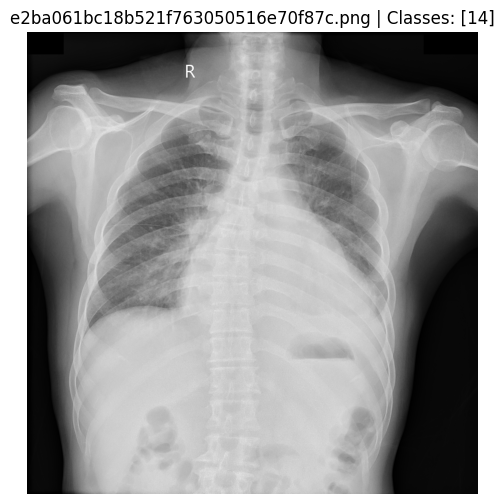

In [15]:
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title(f"{sample_file} | Classes: {classes}")
plt.axis("off")
plt.show()


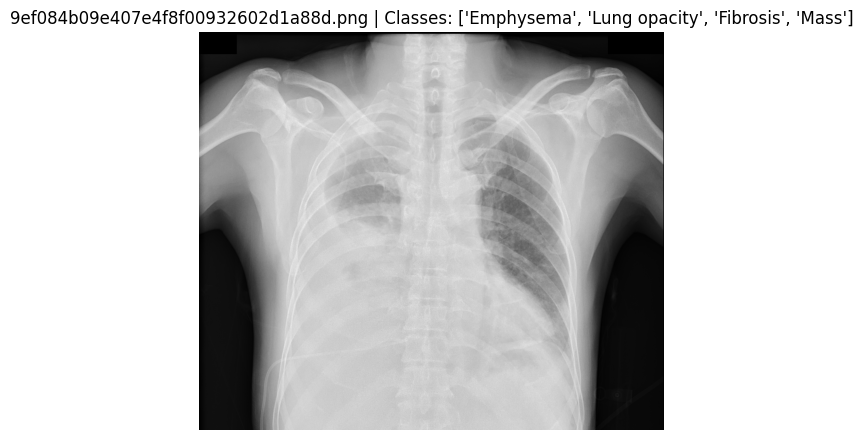

In [16]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import random

# Paths
OUTPUT_DIR = "/kaggle/working/png_5000_balanced"
CSV_PATH = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv"

# Load CSV
df = pd.read_csv(CSV_PATH)

# Class ID → Name mapping
class_map = {
    0: "Aortic enlargement",
    1: "Atelectasis",
    2: "Calcification",
    3: "Cardiomegaly",
    4: "Consolidation",
    5: "Edema",
    6: "Emphysema",
    7: "Fibrosis",
    8: "Fracture",
    9: "Lung lesion",
    10: "Lung opacity",
    11: "Mass",
    12: "Nodule",
    13: "Pleural effusion",
    14: "No finding"
}

# Pick a random PNG
files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".png")]
sample_file = random.choice(files)
image_id = sample_file.replace(".png","")

# Get class IDs for this image
class_ids = df[df['image_id']==image_id]['class_id'].unique().tolist()
class_names = [class_map[c] for c in class_ids]

# Read image
img = cv2.imread(os.path.join(OUTPUT_DIR, sample_file), cv2.IMREAD_GRAYSCALE)

# Display
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title(f"{sample_file} | Classes: {class_names}")
plt.axis("off")
plt.show()
